In [1]:
# Inspekterar dataset struktur och klassbalans
import os
import tensorflow as tf

# sökväg till mappen som innehåller datan
data_dir = "D:/_DATA SCIENCE/DeepLearning/expressions_dl/FER-2013"

train_path = os.path.join(data_dir, 'train')
class_names = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])
print(f"Klassnamn: {class_names}")
print(f"Antal klasser: {len(class_names)}")

# Räknar bilder per klass
for cls in class_names:
    train_cls_path = os.path.join(train_path, cls)
    test_cls_path = os.path.join(data_dir, 'test', cls)
    n_train = len([f for f in os.listdir(train_cls_path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
    n_test = len([f for f in os.listdir(test_cls_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]) if os.path.exists(test_cls_path) else 0
    
    print(f"  {cls}: train={n_train}, test={n_test}")

Klassnamn: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Antal klasser: 7
  angry: train=3995, test=958
  disgust: train=436, test=111
  fear: train=4097, test=1024
  happy: train=7215, test=1774
  neutral: train=4965, test=1233
  sad: train=4830, test=1247
  surprise: train=3171, test=831


In [2]:
# Laddar lite  mindre delmängd med gråskalor
IMG_SIZE = 48
BATCH_SIZE = 32
SEED = 42


full_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int',
    color_mode='grayscale'
)

full_val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int',
    color_mode='grayscale'
)

TRAIN_BATCHES = 80
VAL_BATCHES = 20

train_ds = full_train_ds.take(TRAIN_BATCHES)
val_ds = full_val_ds.take(VAL_BATCHES)

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.


In [4]:
# Bygger CNN för gråskalebilder
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model.summary()

c:\Users\riera\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Kompilerar och tränar modellen på liten delmängd
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS = 10   # först bara 10 epoker – snabbt test
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2605 - loss: 1.8245 - val_accuracy: 0.2453 - val_loss: 1.8411
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.2766 - loss: 1.8045 - val_accuracy: 0.2484 - val_loss: 1.8148
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.2809 - loss: 1.7695 - val_accuracy: 0.2516 - val_loss: 1.7921
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3141 - loss: 1.7018 - val_accuracy: 0.3313 - val_loss: 1.6992
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3535 - loss: 1.6261 - val_accuracy: 0.3594 - val_loss: 1.7285
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4148 - loss: 1.5502 - val_accuracy: 0.3328 - val_loss: 1.6656
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4465 - loss: 1.4768 - val_accuracy: 0.3781 - val_loss: 1.6088
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4617 - loss: 1.4307 - val_accuracy: 0.3969 - v

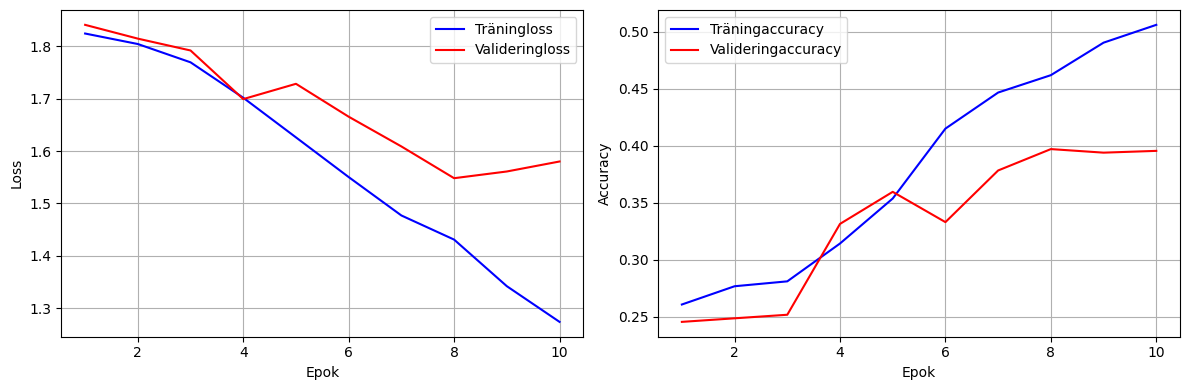

In [7]:
# Ritar träningskurvor (loss och accuracy)

import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(1, len(train_loss)+1)


plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs_range, train_loss, 'b-', label='Träningloss')
plt.plot(epochs_range, val_loss, 'r-', label='Valideringloss')
plt.xlabel('Epok')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs_range, train_acc, 'b-', label='Träningaccuracy')
plt.plot(epochs_range, val_acc, 'r-', label='Valideringaccuracy')
plt.xlabel('Epok')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

In [8]:
# Laddar testdata (gråskala, ingen valideringssplit)

test_path = os.path.join(data_dir, 'test')
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int',
    color_mode='grayscale',
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# Utvärderar modellen som vi precis tränat på bara liten delmängd

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test-loss: {test_loss:.4f}, Test-accuracy: {test_acc:.4f}")

Found 7178 files belonging to 7 classes.
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4166 - loss: 1.5224
Test-loss: 1.5224, Test-accuracy: 0.4166


Modellen tränad på den lilla delmängd ger c.a 41–42 % test-accuracy. Pekar lite på overfitting (jämfört med träning accuracy 54%). Modellen generaliserar dåligt. Förväntade detta med tanken på datamängd som e liten

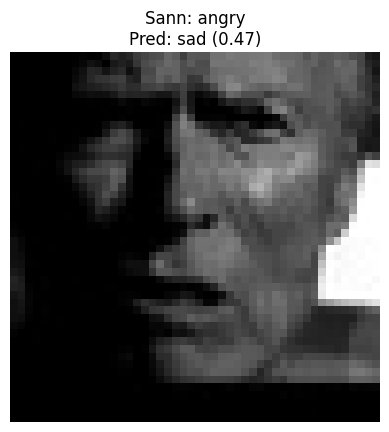

Sann: angry, Pred: sad (säkerhet: 0.47)


In [9]:
# Nu gör prediktion på en slump testbild (med delmängd modell)

import random
import numpy as np

for images, labels in test_ds.take(1):
    idx = random.randint(0, len(images)-1)
    image = images[idx]
    true_label = labels[idx].numpy()
    img_batch = np.expand_dims(image.numpy(), axis=0)
    pred = model.predict(img_batch, verbose=0)
    pred_class = np.argmax(pred[0])
    confidence = np.max(pred[0])
    
    plt.imshow(image.numpy().squeeze(), cmap='gray')
    plt.title(f"Sann: {class_names[true_label]}\nPred: {class_names[pred_class]} ({confidence:.2f})")
    plt.axis('off')
    plt.show()
    
    print(f"Sann: {class_names[true_label]}, Pred: {class_names[pred_class]} (säkerhet: {confidence:.2f})")
    break

Här testar jag modellen (tränad på liten delmängd) på en slump testbild.

Modellen gissade `sad` men rätt svar var `angry`. Säkerheten är bara 47%, vilket är lågt. Det visar att modellen är osäker och ofta har fel – tror på grund av lite träningsdata och overfitting.

### -------------------------------------------------------------------------------

### Träning på hela datasetet (utan begränsning)

Nu när pipelinen fungerar med en liten delmängd, går vi upp till fullständig träning data.  
Vi använder samma modellarkitektur och tränar i fler epoker.

In [10]:
# Laddar hela datasetet (ingen begränsning)

normalization_layer = tf.keras.layers.Rescaling(1./255)

full_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(48,48),
    batch_size=32,
    label_mode='int',
    color_mode='grayscale'
)

full_val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(48,48),
    batch_size=32,
    label_mode='int',
    color_mode='grayscale'
)


full_train_ds = full_train_ds.map(lambda x, y: (normalization_layer(x), y))
full_val_ds = full_val_ds.map(lambda x, y: (normalization_layer(x), y))
full_train_ds = full_train_ds.prefetch(tf.data.AUTOTUNE)
full_val_ds = full_val_ds.prefetch(tf.data.AUTOTUNE)


Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.


In [11]:
# Bygger samma CNN-modell för träning på hela dataset

from tensorflow.keras import layers, models

model_full = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(7, activation='softmax')
])


model_full.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_full.summary()

c:\Users\riera\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Tränar modellen på hela datasetet (fler epoker)

EPOCHS_FULL = 15

history_full = model_full.fit(full_train_ds, validation_data=full_val_ds, epochs=EPOCHS_FULL)

Epoch 1/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.3389 - loss: 1.6603 - val_accuracy: 0.4179 - val_loss: 1.5070
Epoch 2/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.4607 - loss: 1.4108 - val_accuracy: 0.4649 - val_loss: 1.3984
Epoch 3/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5149 - loss: 1.2820 - val_accuracy: 0.5173 - val_loss: 1.2850
Epoch 4/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5469 - loss: 1.1916 - val_accuracy: 0.5166 - val_loss: 1.2651
Epoch 5/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5786 - loss: 1.1153 - val_accuracy: 0.5212 - val_loss: 1.2496
Epoch 6/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6020 - loss: 1.0498 - val_accuracy: 0.5370 - val_loss: 1.2305
Epoch 7/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6337 - loss: 0.9795 - val_accuracy: 0.5288 - val_loss: 1.2605
Epoch 8/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.6631 - loss: 0.9116 - 

In [ ]:
# Utvärderar den full tränade modellen på testdata

test_loss_full, test_acc_full = model_full.evaluate(test_ds, verbose=1)

print(f"Test-loss: {test_loss_full:.4f}, Test-accuracy: {test_acc_full:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5199 - loss: 1.8753
Test-loss: 1.8753, Test-accuracy: 0.5199


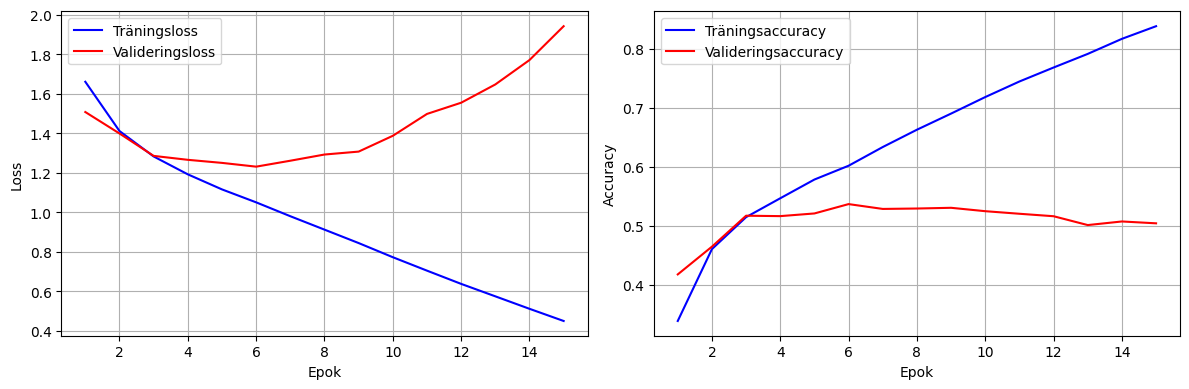

In [14]:
# Visualiserar träningskurvor för full modell

import matplotlib.pyplot as plt

train_loss = history_full.history['loss']
val_loss = history_full.history['val_loss']
train_acc = history_full.history['accuracy']
val_acc = history_full.history['val_accuracy']
epochs = range(1, len(train_loss)+1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, train_loss, 'b-', label='Träningsloss')
plt.plot(epochs, val_loss, 'r-', label='Valideringsloss')
plt.xlabel('Epok')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.subplot(1,2,2)
plt.plot(epochs, train_acc, 'b-', label='Träningsaccuracy')
plt.plot(epochs, val_acc, 'r-', label='Valideringsaccuracy')
plt.xlabel('Epok')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)



plt.tight_layout()
plt.show()

- Väldigt widening kurvor. Inte jättefint    :-/

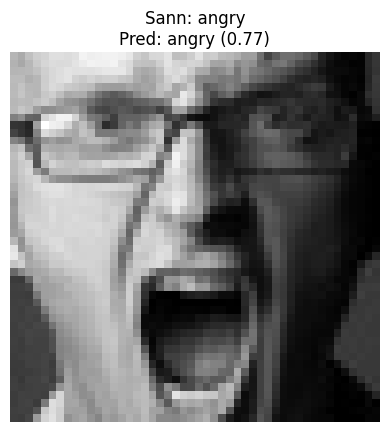

Sann: angry, Pred: angry (säkerhet: 0.77)


In [15]:
# Gör en prediktion på en testbild (full modell)

import random
import numpy as np

for images, labels in test_ds.take(1):
    idx = random.randint(0, len(images)-1)
    image = images[idx]
    true_label = labels[idx].numpy()
    img_batch = np.expand_dims(image.numpy(), axis=0)
    pred = model_full.predict(img_batch, verbose=0)
    pred_class = np.argmax(pred[0])
    confidence = np.max(pred[0])
    
    
    plt.imshow(image.numpy().squeeze(), cmap='gray')
    plt.title(f"Sann: {class_names[true_label]}\nPred: {class_names[pred_class]} ({confidence:.2f})")
    plt.axis('off')
    plt.show()
    
    print(f"Sann: {class_names[true_label]}, Pred: {class_names[pred_class]} (säkerhet: {confidence:.2f})")
    break

# Analys och reflektion

## Hur bra fungerar modellen?
Modellen klarar cirka 52 % rätt på testdata. Det är bättre än att gissa slumpmässigt (14%), men inte tillräckligt bra för verklig användning.

## Ser du tecken på overfitting eller underfitting?
Ja, overfitting. Träningsaccuracy blir mycket högre än valideringsaccuracy. Kurvorna widening mot slutet.

## Skillnad mellan tränings- och testdata?
Testresultatet (52%) är ungefär samma som sista valideringsresultatet. Båda är lägre än träningsresultatet, och visar overfitting.

## Vad påverkar resultatet mest?
Mängden träningsdata, modellens storlek (för många parametrar säkert) och att jag inte använde regularisering som dropout.

## Vilka begränsningar har modellen?
Låg accuracy, osäkra prediktioner, fungerar säkert dåligt på bilder utanför datasetet.

---

## Vad var svårast?
Att få datapipelinen rätt (gråskala, normalisering) och att tolka overfitting i kurvorna.

## Vad lärde du dig?
Bygga CNN, ladda bilder med Keras, träna och utvärdera, se overfitting.

## Vad hade du gjort annorlunda?
Lag till dropout, early stopping, dataaugmentering och testat transfer learning.



In [16]:
# Sparar den tränade modellen

model_full.save("expression_model.keras")